# Construct End-User HDF5 Files

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import glob
import awkward as ak
import itertools
import yaml
import os
import sys
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
from typing import List
import h5py
atl.ATLAS = "ColliderML"

sys.path.append("../")
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent
from utils import load_root_file

## Roadmap

1. Load in edm4hep file
4. Load in measurements root
5. Load in trackstates ambi roo
8. Digihit object needs:
    - ...

# Loading

In [2]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0"
event_num = 0

In [2]:
base_dir = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v4/runs/0"
event_num = 0

## 1. Load in edm4hep file

In [ ]:
event = EDM4hepEvent(os.path.join(base_dir, "edm4hep.root"), event_index=event_num)

Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v4/runs/0/edm4hep.root...
  Loaded 701148 particles.
  Loaded 202101 tracker hits.


In [ ]:
tracker_df = event.get_tracker_hits_df()
tracker_df.columns

# Cast x,y,z to float32
tracker_df[["x", "y", "z"]] = tracker_df[["x", "y", "z"]].astype(np.float32)

# Sort by x,y,z
tracker_df = tracker_df.sort_values(by=["x", "y", "z"])

# DigiHits Objects

In [5]:
digihits_path = "/global/cfs/cdirs/m4958/data/ColliderML/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/measurements.root"
simhits_path = "/global/cfs/cdirs/m4958/data/ColliderML/outputs/low_pileup_pilot/gg2ttbar/v1/runs/0/simhits.root"

In [ ]:
digihits_path = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v4/runs/0/measurements.root"
simhits_path = "/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_mini_pilot/ttbar/v4/runs/0/simhits.root"

In [ ]:
# uproot load digihits file

digihits_df = load_root_file(digihits_path)
simhits_df = load_root_file(simhits_path)

# Cast true_x,true_y,true_z to float32
digihits_df[["true_x", "true_y", "true_z"]] = digihits_df[["true_x", "true_y", "true_z"]].astype(np.float32)

# Sort by true_x,true_y,true_z
digihits_df = digihits_df.sort_values(by=["true_x", "true_y", "true_z"])

In [ ]:
digihits_df = digihits_df[digihits_df.event_nr == 0]
simhits_df = simhits_df[simhits_df.event_id == 0]

In [ ]:
digihits_df.columns

Index(['event_nr', 'volume_id', 'layer_id', 'surface_id', 'extra_id',
       'rec_loc0', 'rec_loc1', 'rec_time', 'var_loc0', 'var_loc1', 'var_time',
       'rec_x', 'rec_y', 'rec_z', 'clus_size', 'clus_size_loc0',
       'clus_size_loc1', 'true_loc0', 'true_loc1', 'true_phi', 'true_theta',
       'true_qop', 'true_time', 'true_x', 'true_y', 'true_z',
       'true_incident_phi', 'true_incident_theta', 'residual_loc0',
       'residual_loc1', 'residual_time', 'pull_loc0', 'pull_loc1',
       'pull_time'],
      dtype='object')

In [ ]:
digihits_df[["rec_x", "rec_y", "rec_z"]]

,rec_x,rec_y,rec_z
entry,,,
196877,-990.874939,-43.740211,2270.5
167739,-989.736816,13.156303,-1904.5
193187,-990.548767,27.434826,1625.5
165939,-991.262878,-63.136681,-2254.5
193170,-991.686707,62.427505,1604.5
...,...,...,...
191427,990.517517,25.872072,1320.5
167437,989.145386,42.725380,-1909.5
196555,990.028748,1.437025,2270.5


In [ ]:
digihits_df[["true_x", "true_y", "true_z"]]

,true_x,true_y,true_z
entry,,,
196877,-1068.791138,-42.139557,2270.427734
167739,-1066.606079,14.651224,-1904.512695
193187,-1065.476685,25.929476,1625.500000
165939,-1065.399048,-61.599911,-2254.500000
193170,-1065.151855,73.616951,1604.525391
...,...,...,...
191427,1065.315308,24.288553,1320.500000
167437,1065.793213,44.278023,-1909.518555
196555,1065.943848,-0.174951,2270.500000


In [ ]:
digihits_df

,event_nr,volume_id,layer_id,surface_id,extra_id,rec_loc0,rec_loc1,rec_time,var_loc0,var_loc1,...,true_y,true_z,true_incident_phi,true_incident_theta,residual_loc0,residual_loc1,residual_time,pull_loc0,pull_loc1,pull_time
entry,,,,,,,,,,,,,,,,,,,,,
196877,0,30,8,132,2,43.748962,NaN,NaN,0.005184,NaN,...,-42.139557,2270.427734,-0.801798,-0.660678,NaN,NaN,NaN,NaN,NaN,NaN
167739,0,28,8,131,2,-13.158935,NaN,NaN,0.005184,NaN,...,14.651224,-1904.512695,1.024611,0.586623,NaN,NaN,NaN,NaN,NaN,NaN
193187,0,30,4,131,2,-27.440313,NaN,NaN,0.005184,NaN,...,25.929476,1625.500000,-1.313042,-1.031947,NaN,NaN,NaN,NaN,NaN,NaN
165939,0,28,6,131,2,63.149311,NaN,NaN,0.005184,NaN,...,-61.599911,-2254.500000,1.172693,1.235735,NaN,NaN,NaN,NaN,NaN,NaN
193170,0,30,4,129,2,-67.561172,NaN,NaN,0.005184,NaN,...,73.616951,1604.525391,-1.215652,-1.393649,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191427,0,30,2,98,2,25.877247,NaN,NaN,0.005184,NaN,...,24.288553,1320.500000,-2.012548,-0.962798,NaN,NaN,NaN,NaN,NaN,NaN
167437,0,28,8,98,2,42.733925,NaN,NaN,0.005184,NaN,...,44.278023,-1909.518555,-1.865486,-0.977858,NaN,NaN,NaN,NaN,NaN,NaN
196555,0,30,8,98,2,1.437313,NaN,NaN,0.005184,NaN,...,-0.174951,2270.500000,-1.214642,-1.198715,NaN,NaN,NaN,NaN,NaN,NaN


First, does digihits and simhits match up?

In [ ]:
tracker_df[["x", "y", "z"]]

,x,y,z
190545,-1068.791138,-42.139557,2270.427734
184239,-1066.606079,14.651224,-1904.512695
197929,-1065.476685,25.929476,1625.500000
183081,-1065.399048,-61.599911,-2254.500000
195656,-1065.151855,73.616951,1604.525391
...,...,...,...
192396,1065.315308,24.288553,1320.500000
182858,1065.793213,44.278023,-1909.518555
194992,1065.943848,-0.174951,2270.500000
180375,1067.133667,-20.759151,-1304.450317


In [ ]:
# Merge digihits_df with tracker_df on left=true_x,true_y,true_z right=x,y,z

merged = pd.merge(digihits_df, tracker_df, left_on=["true_x", "true_y", "true_z"], right_on=["x", "y", "z"], how="left")

In [ ]:
merged

,event_nr,volume_id,layer_id,surface_id,extra_id,rec_loc0,rec_loc1,rec_time,var_loc0,var_loc1,...,pz,EDep,particle_id,detector,r,R,phi,theta,eta,pt
0,0,30,8,132,2,43.748962,NaN,NaN,0.005184,NaN,...,0.044535,0.000053,72641,LongStripEndcapReadout,1069.621569,2509.767295,-3.102186,0.440270,1.497176,0.071701
1,0,28,8,131,2,-13.158935,NaN,NaN,0.005184,NaN,...,-0.000186,0.000364,334764,LongStripEndcapReadout,1066.706643,2182.895203,3.127857,2.631033,-1.343335,0.000302
2,0,30,4,131,2,-27.440313,NaN,NaN,0.005184,NaN,...,1.666867,0.000113,27501,LongStripEndcapReadout,1065.792141,1943.749762,3.117261,0.580351,1.208637,1.089141
3,0,28,6,131,2,63.149311,NaN,NaN,0.005184,NaN,...,-1.213506,0.000099,50229,LongStripEndcapReadout,1067.178412,2494.321554,-3.083838,2.699488,-1.492878,0.662564
4,0,30,4,129,2,-67.561172,NaN,NaN,0.005184,NaN,...,-0.000276,0.000275,345300,LongStripEndcapReadout,1067.692853,1927.295968,3.072588,0.587143,1.196314,0.000114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202092,0,30,2,98,2,25.877247,NaN,NaN,0.005184,NaN,...,0.954179,0.000124,61722,LongStripEndcapReadout,1065.592131,1696.822572,0.022795,0.678971,1.040839,0.802868
202093,0,28,8,98,2,42.733925,NaN,NaN,0.005184,NaN,...,0.018524,0.000002,264388,LongStripEndcapReadout,1066.712570,2187.266991,0.041521,2.632149,-1.345621,0.013690
202094,0,30,8,98,2,1.437313,NaN,NaN,0.005184,NaN,...,1.313447,0.000119,45020,LongStripEndcapReadout,1065.943861,2508.267642,-0.000164,0.438931,1.500322,0.708167
202095,0,28,12,97,2,-19.241468,NaN,NaN,0.005184,NaN,...,-0.010930,0.000020,95649,LongStripEndcapReadout,1067.335607,1685.466111,-0.019451,2.455836,-1.030080,0.010992


In [ ]:
merged["res_x"] = merged.rec_x - merged.true_x
merged["res_y"] = merged.rec_y - merged.true_y
merged["res_z"] = merged.rec_z - merged.true_z

<Axes: ylabel='Count'>

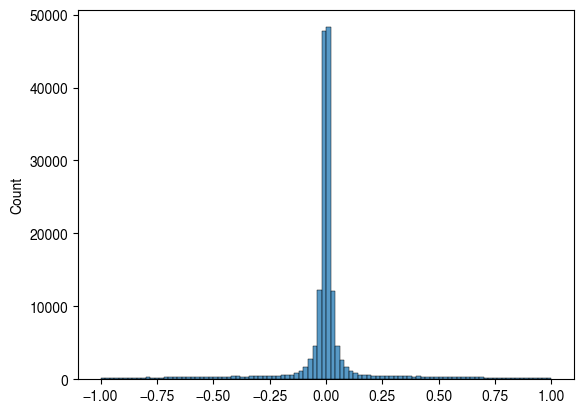

In [ ]:
sns.histplot(merged.res_x, binrange=(-1, 1), bins=100)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

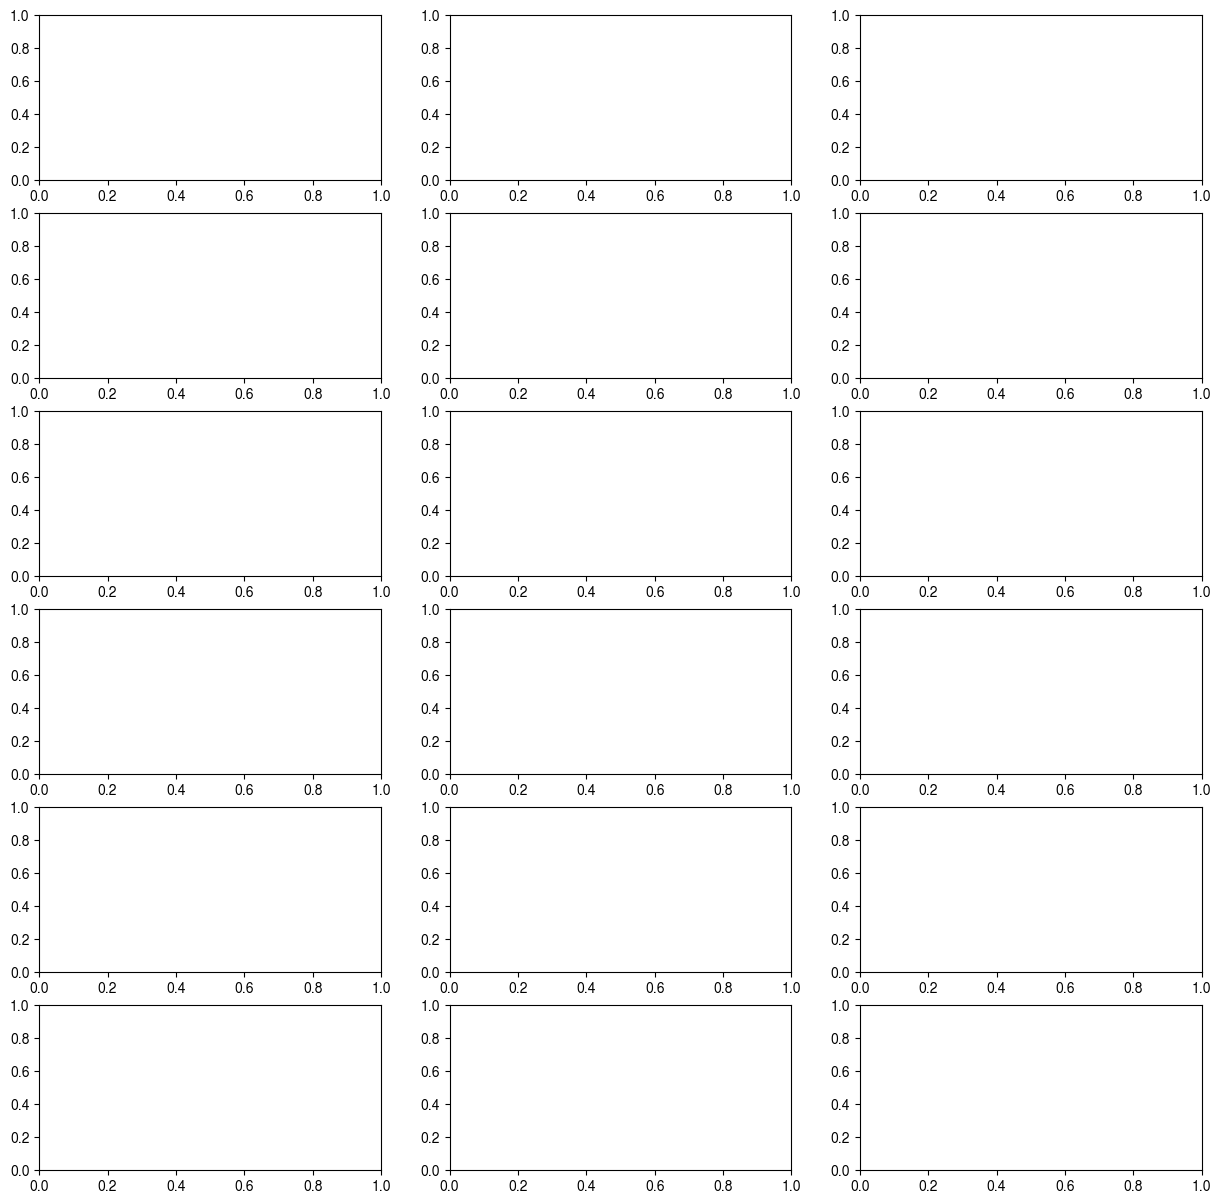

In [ ]:
num_regions = len(merged.detector.unique())

fig, axs = plt.subplots(num_regions, 3, figsize=(15, 15))

for i, region in enumerate(merged.detector.unique()):
    merged_region = merged[merged.detector == region]
    merged_region.res_x.hist(ax=axs[i, 0])
    merged_region.res_y.hist(ax=axs[i, 1])
    merged_region.res_z.hist(ax=axs[i, 2])
    # title and axes labels
    axs[i, 0].set_title(f"Residuals x for {region}")
    axs[i, 0].set_xlabel("Residuals x")
    axs[i, 0].set_ylabel("Count")
    axs[i, 1].set_title(f"Residuals y for {region}")
    axs[i, 1].set_xlabel("Residuals y")
    axs[i, 1].set_ylabel("Count")
    axs[i, 2].set_title(f"Residuals z for {region}")
    break

plt.tight_layout()
plt.show()


## Local to Global Conversion

In [ ]:
import uproot
import numpy as np

import acts
import acts.examples as ax



ModuleNotFoundError: No module named 'acts'

In [ ]:
# 1) Load the same geometry
geo_dir = ax.odd.getOpenDataDetectorDirectory()
det = ax.odd.getOpenDataDetector(odd_dir=geo_dir, materialDecorator=acts.IMaterialDecorator.fromFile(geo_dir / "data/odd-material-maps.root"))
tg = det.trackingGeometry()

# 2) Build converter with a minimal config: only surfaceByIdentifier is required
cfg = ax.DigitizationAlgorithm.Config()
cfg.surfaceByIdentifier = tg.geoIdSurfaceMap()
conv = ax.DigitizationCoordinatesConverter(cfg)

# 3) Read measurements.root
with uproot.open("/path/to/measurements.root") as f:
    t = f["measurements"]
    vol = t["volume_id"].array(library="np")
    lay = t["layer_id"].array(library="np")
    sen = t["surface_id"].array(library="np")
    ext = t["extra_id"].array(library="np")
    loc0 = t["rec_loc0"].array(library="np")
    loc1 = t["rec_loc1"].array(library="np")

# 4) Rebuild geometry id and convert
def make_gid(v, l, s, e):
    gid = acts.GeometryIdentifier()
    gid = gid.withVolume(int(v)).withLayer(int(l)).withSensitive(int(s)).withExtra(int(e))
    return gid.value()

gids = np.array([make_gid(v, l, s, e) for v, l, s, e in zip(vol, lay, sen, ext)], dtype=np.uint64)

xyz = np.array([conv.localToGlobal(int(g), float(x), float(y)) for g, x, y in zip(gids, loc0, loc1)], dtype=float)
x, y, z = xyz[:,0], xyz[:,1], xyz[:,2]